# 03 — Feature selection + Random Forest bản cuối (Tuần 3, Bạn B)

Nối tiếp `02_train_rf_v1.ipynb`. Ba việc của Tuần 3 (Plan.md mục 3):

1. **Feature selection** — từ `feature_importances_` của RF v1 (81 đặc trưng) cắt xuống ~30–42 đặc trưng, xác nhận bằng ROC-AUC 5-fold trên tập train.
2. **Train lại bản cuối** trên tập rút gọn + một bản **"chỉ đặc trưng nhanh"** (bỏ 5 đặc trưng tra cứu ngoài) cho nhánh fallback khi RDAP/WHOIS/Google timeout.
3. **So sánh XGBoost** trên cùng 30 đặc trưng.

Toàn bộ tính toán nặng nằm ở `src/feature_selection.py` và `src/train_rf_final.py`; notebook chỉ gọi lại và trình bày.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import pandas as pd
from IPython.display import Image, display
RF_FINAL = ROOT / 'reports' / 'rf_final'
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 20)
print(ROOT)

E:\DACNTT\URL phishing


## 1. Feature selection

`src/feature_selection.py` thử các mốc cắt (top-k, ngưỡng importance, tổng tích luỹ) và chấm ROC-AUC 5-fold trên **tập train** với đúng cấu hình RF tốt nhất của v1 (chỉ danh sách đặc trưng thay đổi). Quy tắc chọn: tập **nhỏ nhất** trong khoảng 30–42 đặc trưng mà ROC-AUC còn trong dung sai `0.002` so với mốc 81 đặc trưng.

In [2]:
from src.feature_selection import run as fs_run
fs = fs_run()  # ghi lại reports/rf_final/feature_selection.csv + selected_features.json

Đã bỏ 1 dòng URL trùng (11430 → 11429).


    bo_cat  n_dac_trung  roc_auc_mean  roc_auc_std  f1_mean  precision_mean  recall_mean
    top_20           20       0.99167      0.00080  0.95999         0.95941      0.96062
    top_25           25       0.99234      0.00080  0.96248         0.96266      0.96237
    top_30           30       0.99235      0.00075  0.96280         0.96307      0.96259
    top_33           33       0.99277      0.00085  0.96490         0.96464      0.96521
imp>=0.005           36       0.99301      0.00088  0.96412         0.96441      0.96390
    top_36           36       0.99301      0.00088  0.96412         0.96441      0.96390
    top_39           39       0.99321      0.00066  0.96535         0.96465      0.96609
imp>=0.003           42       0.99298      0.00073  0.96522         0.96509      0.96543
    top_42           42       0.99298      0.00073  0.96522         0.96509      0.96543
 cum>=0.98           48       0.99318      0.00070  0.96684         0.96721      0.96653
    top_50           

In [3]:
sel = pd.read_csv(RF_FINAL / 'feature_selection.csv')
display(sel)
meta = json.loads((RF_FINAL / 'selected_features.json').read_text(encoding='utf-8'))
print('Bộ cắt được chọn :', meta['bo_cat_duoc_chon'], '->', meta['n_dac_trung'], 'đặc trưng')
print('ROC-AUC chọn / 81 :', meta['roc_auc_duoc_chon'], '/', meta['roc_auc_moc_81'])
print('Bản fast bỏ       :', meta['dac_trung_ngoai_bi_loai_o_ban_fast'])

,bo_cat,n_dac_trung,roc_auc_mean,roc_auc_std,f1_mean,precision_mean,recall_mean
0,top_20,20,0.99167,0.00080,0.95999,0.95941,0.96062
1,top_25,25,0.99234,0.00080,0.96248,0.96266,0.96237
2,top_30,30,0.99235,0.00075,0.96280,0.96307,0.96259
3,top_33,33,0.99277,0.00085,0.96490,0.96464,0.96521
4,imp>=0.005,36,0.99301,0.00088,0.96412,0.96441,0.96390
5,top_36,36,0.99301,0.00088,0.96412,0.96441,0.96390
6,top_39,39,0.99321,0.00066,0.96535,0.96465,0.96609
7,imp>=0.003,42,0.99298,0.00073,0.96522,0.96509,0.96543
8,top_42,42,0.99298,0.00073,0.96522,0.96509,0.96543
9,cum>=0.98,48,0.99318,0.00070,0.96684,0.96721,0.96653


Bộ cắt được chọn : top_30 -> 30 đặc trưng
ROC-AUC chọn / 81 : 0.99235 / 0.99353
Bản fast bỏ       : ['domain_registration_length', 'domain_age', 'web_traffic', 'google_index', 'page_rank']


Danh sách 30 đặc trưng đã được chốt vào `src/contracts.py::MODEL_FEATURES_FINAL` (và `FAST_FEATURES_FINAL` = 25 đặc trưng, bỏ nhóm tra cứu ngoài).

In [4]:
from src.contracts import MODEL_FEATURES_FINAL, FAST_FEATURES_FINAL
assert list(MODEL_FEATURES_FINAL) == meta['MODEL_FEATURES_FINAL'], 'contracts lệch selected_features.json'
print(len(MODEL_FEATURES_FINAL), 'đặc trưng FINAL'); print(list(MODEL_FEATURES_FINAL))
print(); print(len(FAST_FEATURES_FINAL), 'đặc trưng FAST'); print(list(FAST_FEATURES_FINAL))

30 đặc trưng FINAL
['length_url', 'length_hostname', 'nb_dots', 'nb_hyphens', 'nb_slash', 'nb_www', 'ratio_digits_url', 'ratio_digits_host', 'length_words_raw', 'char_repeat', 'shortest_word_host', 'shortest_word_path', 'longest_words_raw', 'longest_word_path', 'avg_words_raw', 'avg_word_host', 'avg_word_path', 'phish_hints', 'nb_hyperlinks', 'ratio_intHyperlinks', 'ratio_extHyperlinks', 'ratio_extRedirection', 'links_in_tags', 'safe_anchor', 'domain_in_title', 'domain_registration_length', 'domain_age', 'web_traffic', 'google_index', 'page_rank']

25 đặc trưng FAST
['length_url', 'length_hostname', 'nb_dots', 'nb_hyphens', 'nb_slash', 'nb_www', 'ratio_digits_url', 'ratio_digits_host', 'length_words_raw', 'char_repeat', 'shortest_word_host', 'shortest_word_path', 'longest_words_raw', 'longest_word_path', 'avg_words_raw', 'avg_word_host', 'avg_word_path', 'phish_hints', 'nb_hyperlinks', 'ratio_intHyperlinks', 'ratio_extHyperlinks', 'ratio_extRedirection', 'links_in_tags', 'safe_anchor',

## 2. Train bản cuối + bản "chỉ đặc trưng nhanh" + XGBoost

`src/train_rf_final.py`: cùng split `random_state=42`, cùng `GridSearchCV` `StratifiedKFold(k=5)` refit theo `roc_auc`. Mất vài phút CPU — chạy lại chỉ khi cần tái tạo.

In [5]:
import os
if not (RF_FINAL / 'summary.json').exists():
    from src.train_rf_final import run as rf_final_run
    rf_final_run()
summary = json.loads((RF_FINAL / 'summary.json').read_text(encoding='utf-8'))
cmp = pd.DataFrame(summary['bang_so_sanh'])
display(cmp)

,mo_hinh,n_dac_trung,kfold_roc_auc,kfold_f1,test_roc_auc,test_f1_phishing,test_accuracy
0,rf_v1_81_thamchieu,81,0.9935,0.9666,0.9924,0.9612,0.9611
1,rf_final,30,0.9923,0.9635,0.9913,0.9543,0.9541
2,rf_fast,25,0.9771,0.9263,0.9762,0.9275,0.9278
3,xgb_final,30,0.9942,0.9692,0.9924,0.9634,0.9633


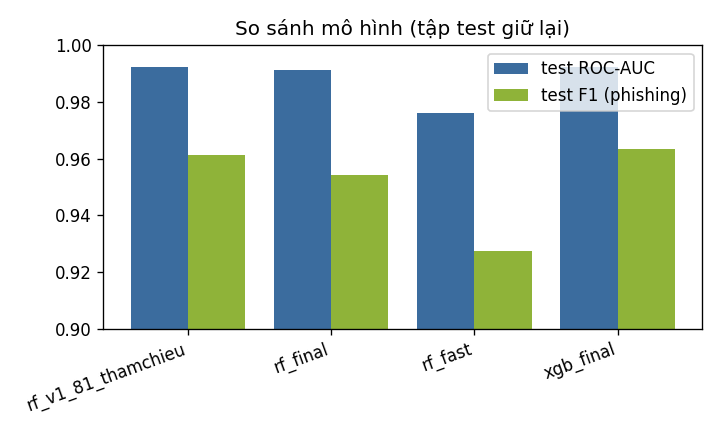

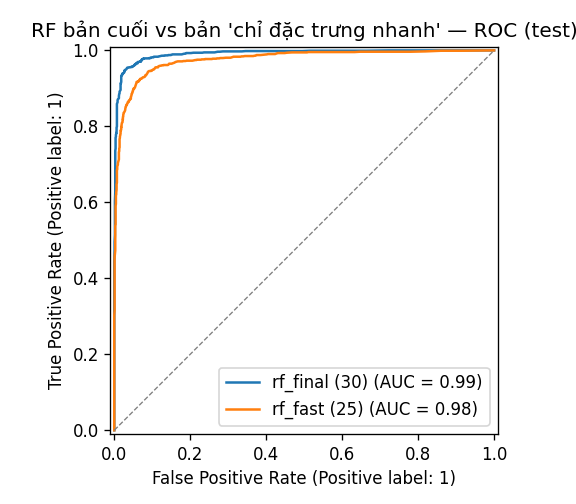

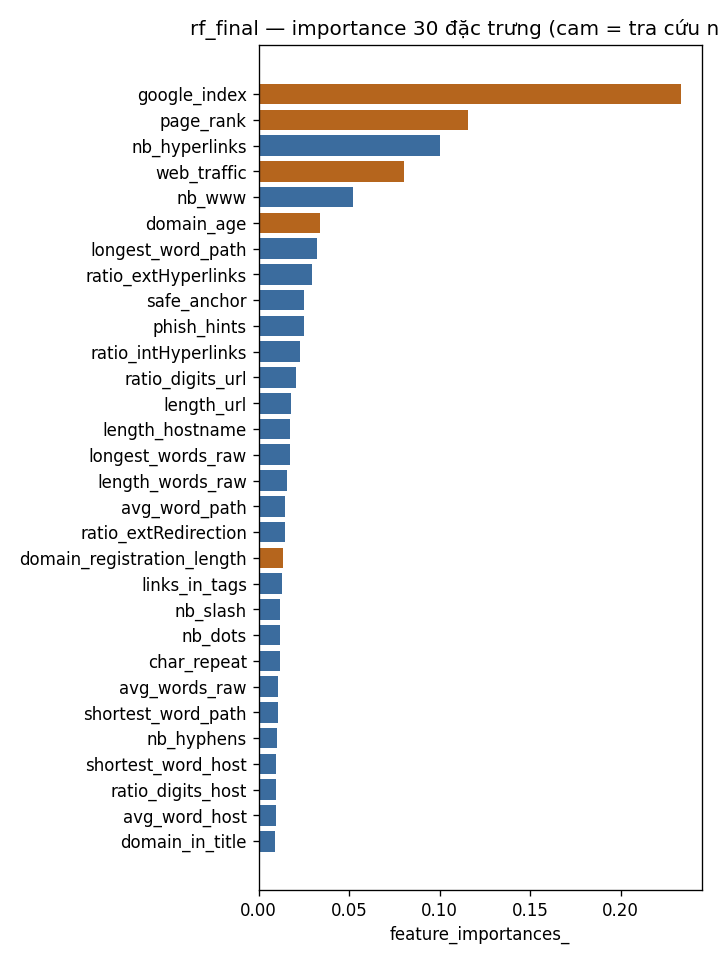

In [6]:
for name in ['fig_so_sanh_mo_hinh.png', 'fig_final_vs_fast_roc.png', 'fig_final_importances.png']:
    p = RF_FINAL / name
    if p.exists(): display(Image(filename=str(p)))

## 3. Đọc kết quả

### 3.1 Cắt 81 → 30 đặc trưng gần như không mất điểm
`rf_final` giữ ~99,9% ROC-AUC của `rf_v1` (81 đặc trưng) với chỉ 37% số đặc trưng. Chi phí: test accuracy giảm ~0,7 điểm.

### 3.2 XGBoost nhỉnh hơn RF trên cùng 30 đặc trưng
`xgb_final` bằng hoặc hơn `rf_v1` ở mọi chỉ số test, huấn luyện nhanh hơn RF ~5 lần. RF vẫn là mô hình theo thiết kế (`CLAUDE.md`: "mô hình nhẹ Random Forest") và `feature_importances_` của RF dễ diễn giải hơn — ghi nhận XGBoost là phương án dự phòng mạnh.

### 3.3 Bỏ tra cứu ngoài thì mô hình yếu đi rõ rệt
`rf_fast` (25 đặc trưng, không mạng) tụt ~2,6 điểm accuracy và ~1,5 điểm ROC-AUC so với `rf_final`. Đây là chi phí định lượng của nhánh fallback khi RDAP/WHOIS/Google timeout → nhánh đó phải dựa thêm vào Luật Override + LLM, không tin `rf_fast` một mình.

In [7]:
ext_final = summary['dac_trung_ngoai_bo_o_fast']
imp = pd.read_csv(RF_FINAL / 'importances_rf_final.csv').set_index('dac_trung')['importance']
print('5 đặc trưng tra cứu ngoài trong bản FINAL chiếm',
      round(float(imp[ext_final].sum()) * 100, 1), '% tổng importance')
print('->', {k: round(float(imp[k]), 3) for k in ext_final})

5 đặc trưng tra cứu ngoài trong bản FINAL chiếm 47.6 % tổng importance
-> {'domain_registration_length': 0.013, 'domain_age': 0.034, 'web_traffic': 0.08, 'google_index': 0.233, 'page_rank': 0.116}


## 4. Override #1 — tuổi domain (RDAP → WHOIS)

`src/override/domain_age.py`. RDAP trước (IANA bootstrap theo TLD), WHOIS fallback, timeout ~500ms/bước. `.vn` không có RDAP → luôn xuống WHOIS. Rỗng cả hai → `flag="unknown"`, **không** mặc định an toàn. Test offline: `tests/test_domain_age.py`.

In [8]:
from datetime import datetime, timedelta, timezone
from src.override import domain_age as da

# minh hoạ offline (không gọi mạng): giả lập ngày đăng ký
orig_rdap, orig_whois = da._rdap_ngay_dang_ky, da._whois_ngay_dang_ky
try:
    da._rdap_ngay_dang_ky = lambda d: datetime.now(timezone.utc) - timedelta(days=12)
    da._whois_ngay_dang_ky = lambda d: None
    print('domain non   :', da.kiem_tra_tuoi_domain('https://vd-moi.com'))
    da._rdap_ngay_dang_ky = lambda d: None
    da._whois_ngay_dang_ky = lambda d: None
    print('không tra được:', da.kiem_tra_tuoi_domain('https://an-danh.vn'))
finally:
    da._rdap_ngay_dang_ky, da._whois_ngay_dang_ky = orig_rdap, orig_whois

domain non   : {'name': 'domain_age', 'flag': True, 'latency_ms': 28.8, 'reason': 'vd-moi.com: đăng ký 2026-08-27 (RDAP), tuổi ~12 ngày (DƯỚI ngưỡng 90 ngày → đáng ngờ).'}
không tra được: {'name': 'domain_age', 'flag': 'unknown', 'latency_ms': 0.0, 'reason': "Không tra được ngày đăng ký của 'an-danh.vn' qua RDAP lẫn WHOIS (không mặc định an toàn)."}


**Chốt Tuần 3:** `MODEL_FEATURES_FINAL` (30) + `FAST_FEATURES_FINAL` (25) trong `contracts.py`; `models/rf_final.joblib`, `models/rf_fast.joblib`, `models/xgb_final.joblib`; Override #1 xong + test. Xem `reports/rf_final/BAO_CAO_RF_FINAL.md`.

Còn nợ: chạy `python -m src.train_rf_final --full` (grid rộng) trước khi khoá số cuối; thêm cờ `domain_age_unknown` khi ghép feature vào service (rủi ro #2 RF v1).